# Fine-tune PhoBERT cho phân loại phản hồi sinh viên

Notebook này dùng để train 3 file đã tiền xử lý:

- `train_cleaned.json`
- `validation_cleaned.json`
- `test_cleaned.json`

Mục tiêu:

- Fine-tune `vinai/phobert-base` trên Google Colab GPU T4.
- Dùng **class weight** để xử lý mất cân bằng nhãn, đặc biệt là nhãn `1 - Neutral`.
- Xuất các chỉ số để so sánh với model khác: Accuracy, Precision, Recall, F1 Macro, F1 Weighted.
- Vẽ và lưu **ma trận nhầm lẫn**.
- Lưu model, tokenizer, kết quả dự đoán và bảng metric.

Quy ước nhãn:

| Label | Ý nghĩa |
|---|---|
| 0 | Negative |
| 1 | Neutral |
| 2 | Positive |

## 1. Cài thư viện

Chạy cell này trên Google Colab. Nếu Colab hỏi restart runtime sau khi cài, hãy restart rồi chạy lại từ đầu.

In [1]:
!pip -q install transformers datasets accelerate evaluate scikit-learn underthesea pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.4 MB/s eta 0:00:00


## 2. Kiểm tra GPU

Nên chọn: `Runtime` → `Change runtime type` → `T4 GPU`.

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

CUDA available: True
GPU: Tesla T4
GPU memory GB: 14.56


## 3. Upload dataset

Cách nhanh nhất: upload trực tiếp 3 file `train_cleaned.json`, `validation_cleaned.json`, `test_cleaned.json` lên Colab.

Sau khi chạy cell bên dưới, chọn đúng 3 file đó.

In [4]:
from google.colab import files
import os

required_files = ["train_cleaned.json", "validation_cleaned.json", "test_cleaned.json"]

missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    print("Thiếu file:", missing)
    uploaded = files.upload()
else:
    print("Đã có đủ 3 file dataset trong thư mục hiện tại.")

Thiếu file: ['test_cleaned.json']


Saving test_cleaned.json to test_cleaned.json
Saving train_cleaned.json to train_cleaned (1).json
Saving validation_cleaned.json to validation_cleaned (1).json


## 4. Import thư viện và cấu hình

Thông số dưới đây tối ưu khá ổn cho Colab T4:

- `MAX_LENGTH = 160`: đủ cho đa số phản hồi sinh viên.
- `BATCH_SIZE = 16`: phù hợp T4 với PhoBERT-base.
- `EPOCHS = 5`: có early stopping nên sẽ tự dừng nếu không cải thiện.
- `metric_for_best_model = macro_f1`: ưu tiên cân bằng cả 3 nhãn, không chỉ accuracy.
- `USE_WORD_SEGMENTATION = True`: phù hợp PhoBERT vì PhoBERT thường hoạt động tốt hơn với dữ liệu tiếng Việt đã tách từ.

In [5]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

MODEL_NAME = "vinai/phobert-base"
NUM_LABELS = 3
MAX_LENGTH = 160
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
SEED = 42
USE_WORD_SEGMENTATION = True

OUTPUT_DIR = "phobert_student_feedback_sentiment"
RESULT_DIR = "results_phobert"
os.makedirs(RESULT_DIR, exist_ok=True)

id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
label2id = {v: k for k, v in id2label.items()}

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 5. Đọc dữ liệu và kiểm tra phân bổ nhãn

In [6]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df = df[["sentence", "sentiment"]].copy()
    df["sentence"] = df["sentence"].astype(str)
    df["sentiment"] = df["sentiment"].astype(int)
    return df

train_df = load_json("train_cleaned.json")
val_df = load_json("validation_cleaned.json")
test_df = load_json("test_cleaned.json")

for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name}: {len(df)} samples")
    display(df["sentiment"].value_counts().sort_index().rename(index=id2label).to_frame("count"))
    display((df["sentiment"].value_counts(normalize=True).sort_index() * 100).round(2).rename(index=id2label).to_frame("percent"))


Train: 11407 samples


,count
sentiment,
Negative,5322
Neutral,458
Positive,5627


,percent
sentiment,
Negative,46.66
Neutral,4.02
Positive,49.33



Validation: 1583 samples


,count
sentiment,
Negative,705
Neutral,73
Positive,805


,percent
sentiment,
Negative,44.54
Neutral,4.61
Positive,50.85



Test: 3165 samples


,count
sentiment,
Negative,1409
Neutral,167
Positive,1589


,percent
sentiment,
Negative,44.52
Neutral,5.28
Positive,50.21


## 6. Kiểm tra trùng lặp và data leakage

Cell này kiểm tra:

- Câu trùng trong từng tập.
- Câu trùng giữa train/validation/test.
- Câu giống nhau nhưng bị gán nhãn khác nhau.

In [7]:
def duplicate_report(df, name):
    exact_dup = df.duplicated(subset=["sentence", "sentiment"]).sum()
    sentence_dup = df.duplicated(subset=["sentence"]).sum()
    conflict = df.groupby("sentence")["sentiment"].nunique()
    conflict_count = (conflict > 1).sum()
    print(f"{name}")
    print("- Duplicate exact sentence + label:", exact_dup)
    print("- Duplicate sentence:", sentence_dup)
    print("- Conflicting labels:", conflict_count)

for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    duplicate_report(df, name)
    print()

train_set = set(train_df["sentence"])
val_set = set(val_df["sentence"])
test_set = set(test_df["sentence"])

print("Leakage Train ∩ Validation:", len(train_set & val_set))
print("Leakage Train ∩ Test:", len(train_set & test_set))
print("Leakage Validation ∩ Test:", len(val_set & test_set))

Train
- Duplicate exact sentence + label: 0
- Duplicate sentence: 0
- Conflicting labels: 0

Validation
- Duplicate exact sentence + label: 0
- Duplicate sentence: 0
- Conflicting labels: 0

Test
- Duplicate exact sentence + label: 0
- Duplicate sentence: 0
- Conflicting labels: 0

Leakage Train ∩ Validation: 4
Leakage Train ∩ Test: 6
Leakage Validation ∩ Test: 0


## 7. Tách từ tiếng Việt cho PhoBERT

PhoBERT thường cho kết quả tốt hơn khi văn bản tiếng Việt được tách từ, ví dụ:

- `sinh viên` → `sinh_viên`
- `giảng viên` → `giảng_viên`

Notebook dùng `underthesea.word_tokenize`. Nếu muốn train nhanh hơn, có thể đổi `USE_WORD_SEGMENTATION = False` ở phần cấu hình.

In [8]:
if USE_WORD_SEGMENTATION:
    from underthesea import word_tokenize

    def segment_text(text):
        return word_tokenize(text, format="text")

    print("Đang tách từ tiếng Việt...")
    train_df["text"] = train_df["sentence"].apply(segment_text)
    val_df["text"] = val_df["sentence"].apply(segment_text)
    test_df["text"] = test_df["sentence"].apply(segment_text)
else:
    train_df["text"] = train_df["sentence"]
    val_df["text"] = val_df["sentence"]
    test_df["text"] = test_df["sentence"]

print("Ví dụ trước/sau:")
print("Original:", train_df.loc[0, "sentence"])
print("Text used:", train_df.loc[0, "text"])

Đang tách từ tiếng Việt...
Ví dụ trước/sau:
Original: slide giáo trình đầy đủ.
Text used: slide giáo_trình đầy_đủ .


## 8. Tính class weight

Vì nhãn `Neutral` ít hơn rất nhiều, model dễ bỏ qua nhãn này. Class weight giúp loss phạt mạnh hơn khi dự đoán sai lớp ít dữ liệu.

Công thức dùng từ `sklearn.compute_class_weight`:

```text
weight_c = total_samples / (num_classes * samples_of_class_c)
```

In [9]:
y_train = train_df["sentiment"].values
classes = np.array([0, 1, 2])
class_weights_np = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

print("Class weights:")
for label_id, weight in enumerate(class_weights_np):
    print(f"{label_id} - {id2label[label_id]}: {weight:.4f}")

pd.DataFrame({
    "label_id": classes,
    "label_name": [id2label[i] for i in classes],
    "count": [Counter(y_train)[i] for i in classes],
    "class_weight": class_weights_np
}).to_csv(os.path.join(RESULT_DIR, "class_weights.csv"), index=False)

Class weights:
0 - Negative: 0.7145
1 - Neutral: 8.3020
2 - Positive: 0.6757


## 9. Tạo HuggingFace Dataset và tokenize

In [10]:
train_dataset = Dataset.from_pandas(train_df[["text", "sentiment"]].rename(columns={"sentiment": "labels"}), preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "sentiment"]].rename(columns={"sentiment": "labels"}), preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "sentiment"]].rename(columns={"sentiment": "labels"}), preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
val_tokenized = val_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
test_tokenized = test_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/11407 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3165 [00:00<?, ? examples/s]

## 10. Khởi tạo model và Weighted Trainer

`WeightedTrainer` ghi đè hàm `compute_loss` để đưa class weight vào `CrossEntropyLoss`.

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
    }

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

## 11. Cấu hình train

Ghi chú:

- `fp16=True`: tận dụng GPU T4 để train nhanh hơn.
- `load_best_model_at_end=True`: tự lấy checkpoint tốt nhất theo `macro_f1`.
- `EarlyStoppingCallback`: tránh overfit.
- `save_total_limit=2`: chỉ giữ 2 checkpoint để tiết kiệm dung lượng.

In [13]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=0,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

## 12. Train model

In [14]:
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation macro F1:", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.558015,0.548168,0.941251,0.854905,0.848150,0.851262,0.941248,0.941251,0.940995
2,0.436930,0.666912,0.950726,0.892625,0.837752,0.860743,0.948563,0.950726,0.948990
3,0.345793,0.844365,0.948200,0.899317,0.819370,0.849964,0.945652,0.948200,0.945571
4,0.264004,0.812670,0.950726,0.891280,0.833659,0.857511,0.948364,0.950726,0.948821


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint: phobert_student_feedback_sentiment/checkpoint-1426
Best validation macro F1: 0.8607425836199175


## 13. Đánh giá trên validation và test

Các metric quan trọng để so sánh model:

- `accuracy`: độ chính xác tổng thể.
- `macro_f1`: trung bình F1 của 3 lớp, rất quan trọng khi dữ liệu mất cân bằng.
- `weighted_f1`: F1 có tính theo tỷ lệ số lượng mẫu từng lớp.
- `classification_report`: xem precision/recall/F1 từng nhãn.

In [15]:
val_metrics = trainer.evaluate(val_tokenized, metric_key_prefix="val")
test_metrics = trainer.evaluate(test_tokenized, metric_key_prefix="test")

metrics_df = pd.DataFrame([
    {"split": "validation", **val_metrics},
    {"split": "test", **test_metrics},
])

display(metrics_df)
metrics_df.to_csv(os.path.join(RESULT_DIR, "phobert_metrics.csv"), index=False)
print("Saved metrics:", os.path.join(RESULT_DIR, "phobert_metrics.csv"))

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


,split,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_precision,val_weighted_recall,val_weighted_f1,val_runtime,...,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1,test_runtime,test_samples_per_second,test_steps_per_second
0,validation,0.665297,0.950726,0.892625,0.837752,0.860743,0.948563,0.950726,0.94899,2.1024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.938073,0.875469,0.812993,0.83771,0.934778,0.938073,0.935318,4.5541,694.984,21.739


Saved metrics: results_phobert/phobert_metrics.csv


## 14. Classification report trên test set

In [16]:
pred_output = trainer.predict(test_tokenized)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=[id2label[i] for i in range(NUM_LABELS)],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(os.path.join(RESULT_DIR, "phobert_classification_report.csv"))
print("Saved report:", os.path.join(RESULT_DIR, "phobert_classification_report.csv"))

,precision,recall,f1-score,support
Negative,0.941989,0.968062,0.954848,1409.000000
Neutral,0.735043,0.514970,0.605634,167.000000
Positive,0.949375,0.955947,0.952650,1589.000000
accuracy,0.938073,0.938073,0.938073,0.938073
macro avg,0.875469,0.812993,0.837710,3165.000000
weighted avg,0.934778,0.938073,0.935318,3165.000000


Saved report: results_phobert/phobert_classification_report.csv


## 15. Ma trận nhầm lẫn

Ma trận nhầm lẫn giúp xem model đang nhầm nhãn nào nhiều nhất. Với dataset này, cần chú ý đặc biệt các lỗi:

- `Neutral → Positive`
- `Neutral → Negative`

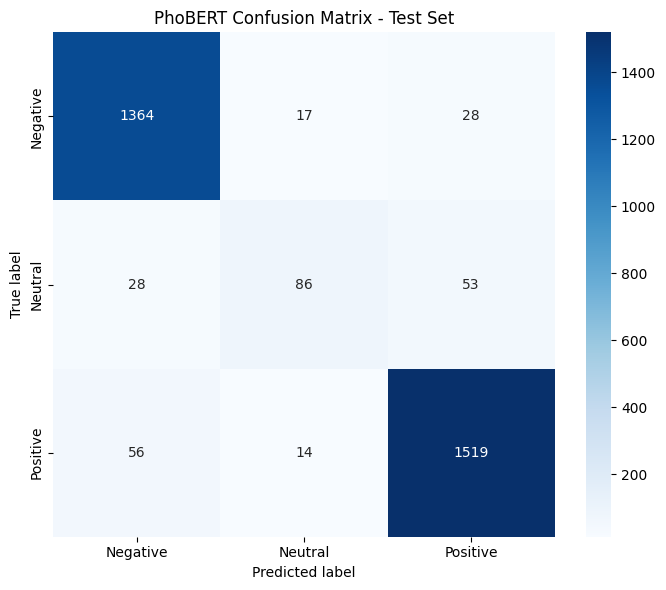

Saved confusion matrix: results_phobert/phobert_confusion_matrix.png


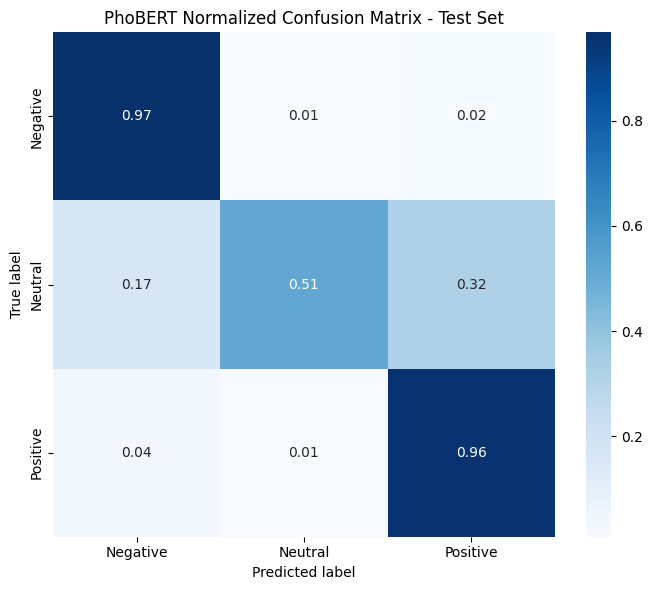

Saved normalized confusion matrix: results_phobert/phobert_confusion_matrix_normalized.png


In [17]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2], normalize="true")

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(NUM_LABELS)],
    yticklabels=[id2label[i] for i in range(NUM_LABELS)]
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("PhoBERT Confusion Matrix - Test Set")
plt.tight_layout()
cm_path = os.path.join(RESULT_DIR, "phobert_confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()
print("Saved confusion matrix:", cm_path)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(NUM_LABELS)],
    yticklabels=[id2label[i] for i in range(NUM_LABELS)]
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("PhoBERT Normalized Confusion Matrix - Test Set")
plt.tight_layout()
cm_norm_path = os.path.join(RESULT_DIR, "phobert_confusion_matrix_normalized.png")
plt.savefig(cm_norm_path, dpi=300)
plt.show()
print("Saved normalized confusion matrix:", cm_norm_path)

## 16. Lưu dự đoán trên test set

File này dùng để phân tích lỗi hoặc so sánh từng mẫu với các model khác.

In [18]:
probs = torch.softmax(torch.tensor(pred_output.predictions), dim=-1).numpy()

pred_df = test_df.copy()
pred_df["true_label"] = y_true
pred_df["true_name"] = [id2label[i] for i in y_true]
pred_df["pred_label"] = y_pred
pred_df["pred_name"] = [id2label[i] for i in y_pred]
pred_df["prob_negative"] = probs[:, 0]
pred_df["prob_neutral"] = probs[:, 1]
pred_df["prob_positive"] = probs[:, 2]
pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

pred_path = os.path.join(RESULT_DIR, "phobert_test_predictions.csv")
pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

display(pred_df.head(20))
print("Saved predictions:", pred_path)

,sentence,sentiment,text,true_label,true_name,pred_label,pred_name,prob_negative,prob_neutral,prob_positive,is_correct
0,nói tiếng anh lưu loát.,2,nói tiếng anh lưu_loát .,2,Positive,2,Positive,0.001793,0.001576,0.996630,True
1,giáo viên rất vui tính.,2,giáo_viên rất vui_tính .,2,Positive,2,Positive,0.001615,0.001195,0.997190,True
2,cô max có tâm.,2,cô max có tâm .,2,Positive,2,Positive,0.001599,0.001186,0.997215,True
3,"giảng bài thu hút, dí dỏm.",2,"giảng bài thu_hút , dí_dỏm .",2,Positive,2,Positive,0.001694,0.000997,0.997309,True
4,"giáo viên không giảng dạy kiến thức, hướng dẫn...",0,"giáo_viên không giảng_dạy kiến_thức , hướng_dẫ...",0,Negative,0,Negative,0.982723,0.002333,0.014944,True
5,thầy dạy nhiệt tình và tâm huyết.,2,thầy dạy nhiệt_tình và tâm_huyết .,2,Positive,2,Positive,0.001553,0.001053,0.997394,True
6,tính điểm thi đua các nhóm.,2,tính điểm thi_đua các nhóm .,2,Positive,1,Neutral,0.001745,0.996813,0.001441,False
7,thầy nhiệt tình giảng lại cho học sinh.,2,thầy nhiệt_tình giảng lại cho học_sinh .,2,Positive,2,Positive,0.001765,0.001897,0.996338,True
8,có đôi lúc nói hơi nhanh làm sinh viên không t...,0,có đôi_lúc nói hơi nhanh làm sinh_viên không t...,0,Negative,0,Negative,0.987249,0.003561,0.009190,True
9,"giảng dạy nhiệt tình, liên hệ thực tế khá nhiề...",2,"giảng_dạy nhiệt_tình , liên_hệ thực_tế khá nhi...",2,Positive,2,Positive,0.001890,0.000946,0.997165,True


Saved predictions: results_phobert/phobert_test_predictions.csv


## 17. Phân tích lỗi nhanh

Cell này hiển thị một số câu model dự đoán sai để dễ viết phần nhận xét trong báo cáo.

In [19]:
wrong_df = pred_df[pred_df["is_correct"] == False].copy()
print("Số câu dự đoán sai:", len(wrong_df))

for true_label in range(NUM_LABELS):
    subset = wrong_df[wrong_df["true_label"] == true_label]
    print(f"\nSai với nhãn thật {true_label} - {id2label[true_label]}: {len(subset)} câu")
    display(subset[["sentence", "true_name", "pred_name", "prob_negative", "prob_neutral", "prob_positive"]].head(10))

Số câu dự đoán sai: 196

Sai với nhãn thật 0 - Negative: 45 câu


,sentence,true_name,pred_name,prob_negative,prob_neutral,prob_positive
165,"có ba buổi học, chỉ những người tham gia buổi ...",Negative,Neutral,0.241498,0.751901,0.006601
271,""" các bạn có hiểu ý thầy không ạ "" ( đáp lại t...",Negative,Neutral,0.023916,0.973671,0.002413
364,"cô cho tài liệu học tập là một trang web, lên ...",Negative,Positive,0.013204,0.051137,0.935659
429,thuyết trình thường xuyên.,Negative,Positive,0.005474,0.014522,0.980004
436,làm bài giảng sinh động.,Negative,Positive,0.001908,0.001731,0.996361
457,bài giảng bằng tiếng anh giúp sinh viên tiếp c...,Negative,Positive,0.003971,0.007107,0.988922
599,dạy kết hợp với các hoạt động liên quan đến bà...,Negative,Positive,0.018444,0.007459,0.974097
639,"thầy dạy tận tâm, nhưng thầy thường nói đến nh...",Negative,Positive,0.002985,0.001736,0.995280
688,dạy full english.,Negative,Positive,0.003236,0.005548,0.991216
704,nắng vào buổi sáng ở gần cửa sổ.,Negative,Positive,0.042921,0.468026,0.489053



Sai với nhãn thật 1 - Neutral: 81 câu


,sentence,true_name,pred_name,prob_negative,prob_neutral,prob_positive
35,môn học này giúp chúng em hiểu ra những vấn đề...,Neutral,Positive,0.003416,0.007789,0.988795
53,như vậy tụi em sẽ định hướng tốt hơn và tập tr...,Neutral,Negative,0.908097,0.020619,0.071284
121,"ví dụ phù hợp với nội dung kiến thức, hướng dẫ...",Neutral,Positive,0.001827,0.002314,0.995858
292,kỹ những chương cuối.,Neutral,Positive,0.166464,0.144909,0.688627
362,cô cho em 10 điểm thực hành colonlove.,Neutral,Positive,0.003055,0.010377,0.986568
443,có kết hợp với bài tập ví dụ.,Neutral,Positive,0.015994,0.125993,0.858014
453,bài tập đầy đủ.,Neutral,Positive,0.002440,0.009444,0.988116
458,có cung cấp tài liệu cho sinh viên.,Neutral,Positive,0.003474,0.008614,0.987912
488,ngoài ra còn nhiều kiến thức ngoài.,Neutral,Positive,0.003761,0.022309,0.973930
511,có demo trực tiếp.,Neutral,Positive,0.009670,0.067359,0.922971



Sai với nhãn thật 2 - Positive: 70 câu


,sentence,true_name,pred_name,prob_negative,prob_neutral,prob_positive
6,tính điểm thi đua các nhóm.,Positive,Neutral,0.001745,0.996813,0.001441
12,trong trường macbook thầy số hai thì không có ...,Positive,Negative,0.984642,0.008586,0.006772
45,phần lớn chỉ là lý thuyết và bài tập.,Positive,Negative,0.987822,0.003035,0.009142
57,đưa nhiều bài tập khó mà có lời giải cho sinh ...,Positive,Negative,0.962218,0.003403,0.034379
79,giảng bài xúc tích.,Positive,Negative,0.874578,0.043756,0.081667
123,cần có nhiều giảng viên như cô dạy hơn.,Positive,Negative,0.981899,0.002391,0.015709
214,cô hoàng toàn không dùng courses hay các phươn...,Positive,Negative,0.969575,0.010440,0.019986
247,"hay giải theo cách của mình, chưa giải thích đ...",Positive,Negative,0.987298,0.002061,0.010641
261,mong cô luôn giữ được phong độ đó.,Positive,Negative,0.889716,0.019239,0.091046
388,"học thầy từ đầu học kỳ một đến tận hết học kỳ,...",Positive,Neutral,0.041767,0.869770,0.088463


## 18. Hàm dự đoán câu mới

In [20]:
def predict_sentiment(text):
    original_text = text
    if USE_WORD_SEGMENTATION:
        from underthesea import word_tokenize
        text = word_tokenize(text, format="text")

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        prob = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        pred = int(np.argmax(prob))

    return {
        "text": original_text,
        "pred_label": pred,
        "pred_name": id2label[pred],
        "prob_negative": float(prob[0]),
        "prob_neutral": float(prob[1]),
        "prob_positive": float(prob[2]),
    }

examples = [
    "thầy giảng bài rất dễ hiểu và nhiệt tình.",
    "môn học khá bình thường, không có gì đặc biệt.",
    "giảng viên dạy khó hiểu và thường xuyên đi trễ."
]

for ex in examples:
    print(predict_sentiment(ex))

{'text': 'thầy giảng bài rất dễ hiểu và nhiệt tình.', 'pred_label': 2, 'pred_name': 'Positive', 'prob_negative': 0.0016516472678631544, 'prob_neutral': 0.0010066779796034098, 'prob_positive': 0.9973416924476624}
{'text': 'môn học khá bình thường, không có gì đặc biệt.', 'pred_label': 0, 'pred_name': 'Negative', 'prob_negative': 0.7971475124359131, 'prob_neutral': 0.1951587200164795, 'prob_positive': 0.007693799678236246}
{'text': 'giảng viên dạy khó hiểu và thường xuyên đi trễ.', 'pred_label': 0, 'pred_name': 'Negative', 'prob_negative': 0.9871013164520264, 'prob_neutral': 0.002249680692330003, 'prob_positive': 0.010649104602634907}


## 19. Nén kết quả để tải về

Sau khi chạy xong, tải file `.zip` về máy. Trong đó có:

- Model PhoBERT đã fine-tune.
- `phobert_metrics.csv`
- `phobert_classification_report.csv`
- `phobert_confusion_matrix.png`
- `phobert_confusion_matrix_normalized.png`
- `phobert_test_predictions.csv`

In [21]:
!zip -r phobert_training_outputs.zip phobert_student_feedback_sentiment results_phobert

from google.colab import files
files.download("phobert_training_outputs.zip")

  adding: phobert_student_feedback_sentiment/ (stored 0%)
  adding: phobert_student_feedback_sentiment/model.safetensors (deflated 16%)
  adding: phobert_student_feedback_sentiment/training_args.bin (deflated 53%)
  adding: phobert_student_feedback_sentiment/vocab.txt (deflated 55%)
  adding: phobert_student_feedback_sentiment/config.json (deflated 53%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/ (stored 0%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/model.safetensors (deflated 16%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/training_args.bin (deflated 53%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/vocab.txt (deflated 55%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/scaler.pt (deflated 64%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/config.json (deflated 53%)
  adding: phobert_student_feedback_sentiment/checkpoint-2852/rng_state.pth (deflated 26%)
  adding: phobert_student_feedba

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. Gợi ý khi so sánh với model khác

Khi train ViBERT hoặc XLM-RoBERTa, nên giữ nguyên các yếu tố sau để so sánh công bằng:

- Cùng train/validation/test split.
- Cùng `MAX_LENGTH`.
- Cùng số epoch hoặc cùng early stopping.
- Cùng metric chính: `macro_f1`.
- Cùng cách xử lý class imbalance nếu có thể.

Bảng nên đưa vào báo cáo:

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|---:|
| PhoBERT | ... | ... | ... | ... | ... |
| ViBERT | ... | ... | ... | ... | ... |
| XLM-RoBERTa | ... | ... | ... | ... | ... |

Với dataset mất cân bằng, **Macro F1 quan trọng hơn Accuracy**.